Shape: (100000, 28)

Dtypes:
 Conflict_Name                                  str
Conflict_Type                                  str
Region                                         str
Start_Year                                   int64
End_Year                                     int64
Status                                         str
Primary_Country                                str
Pre_War_Unemployment_%                     float64
During_War_Unemployment_%                  float64
Unemployment_Spike_Percentage_Points       float64
Most_Affected_Sector                           str
Youth_Unemployment_Change_%                float64
Pre_War_Poverty_Rate_%                     float64
During_War_Poverty_Rate_%                  float64
Extreme_Poverty_Rate_%                     float64
Food_Insecurity_Rate_%                     float64
Households_Fallen_Into_Poverty_Estimate      int64
GDP_Change_%                               float64
Inflation_Rate_%                           float64
C

C:\Users\kefya\AppData\Local\Temp\ipykernel_20352\39271907.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include="object").columns
C:\Users\kefya\AppData\Local\Temp\ipykernel_20352\39271907.py:83: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/mig


Missing after imputation:
 conflict_name                                   0
conflict_type                                   0
region                                          0
start_year                                      0
end_year                                        0
status                                          0
primary_country                                 0
pre_war_unemployment_                           0
during_war_unemployment_                        0
unemployment_spike_percentage_points            0
most_affected_sector                            0
youth_unemployment_change_                      0
pre_war_poverty_rate_                           0
during_war_poverty_rate_                        0
extreme_poverty_rate_                           0
food_insecurity_rate_                           0
households_fallen_into_poverty_estimate         0
gdp_change_                                     0
inflation_rate_                                 0
currency_devaluation_ 

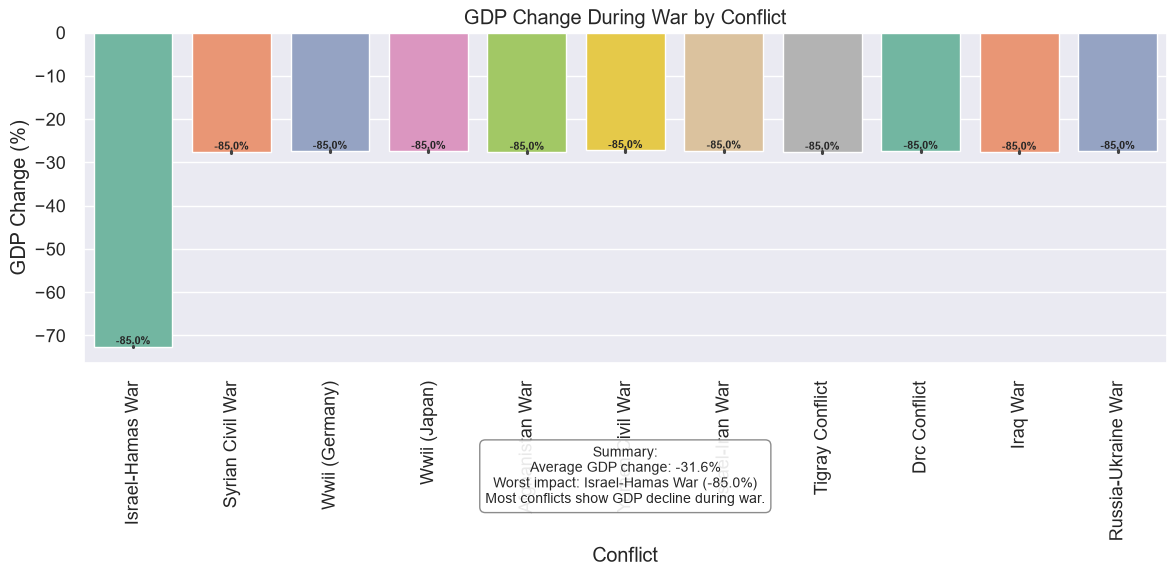

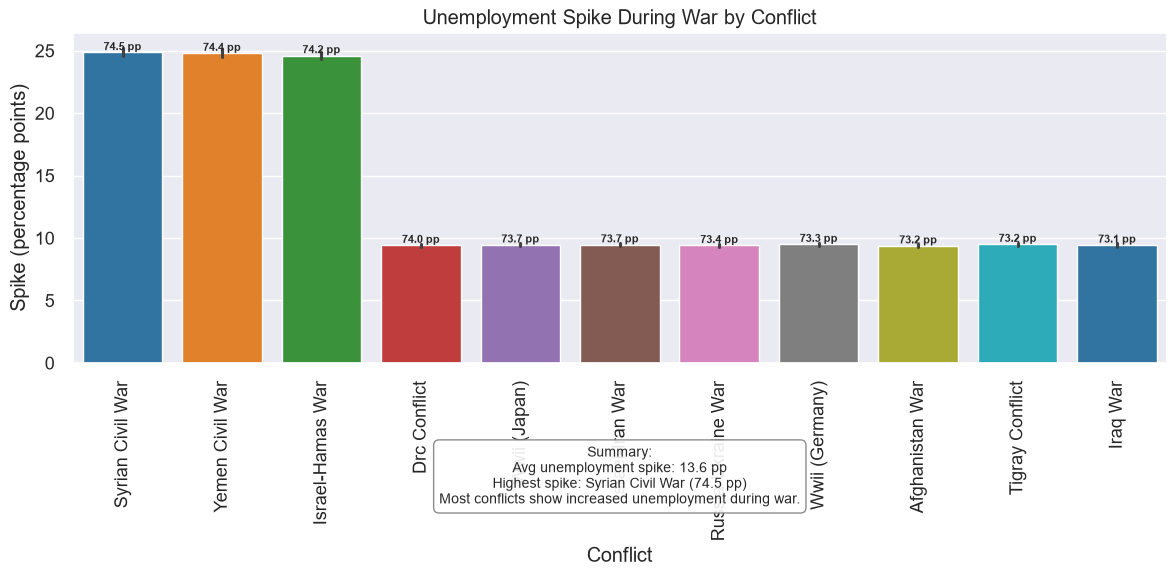

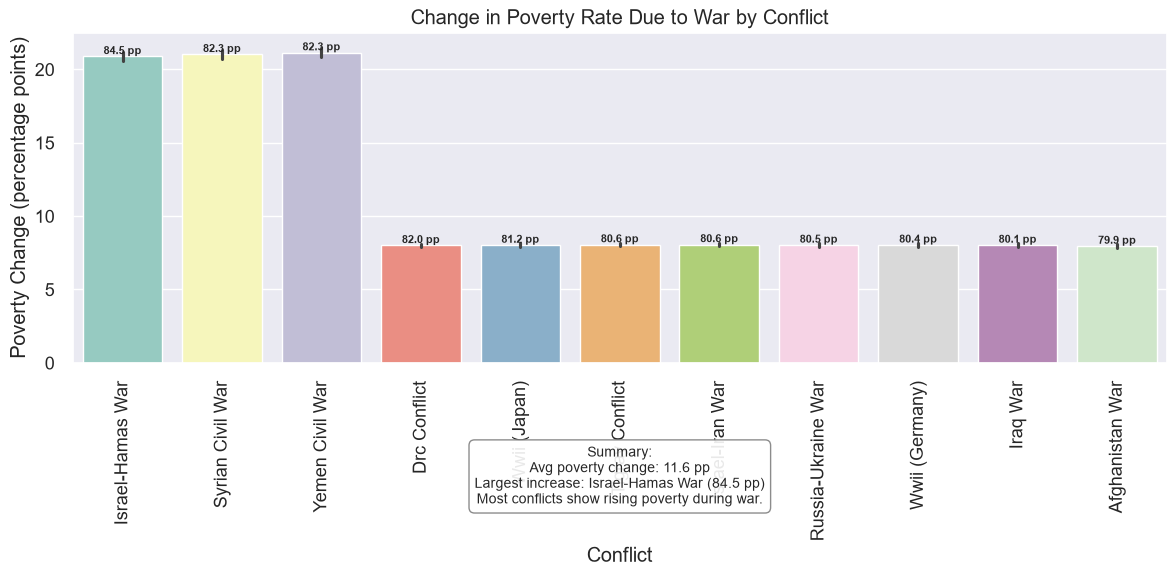

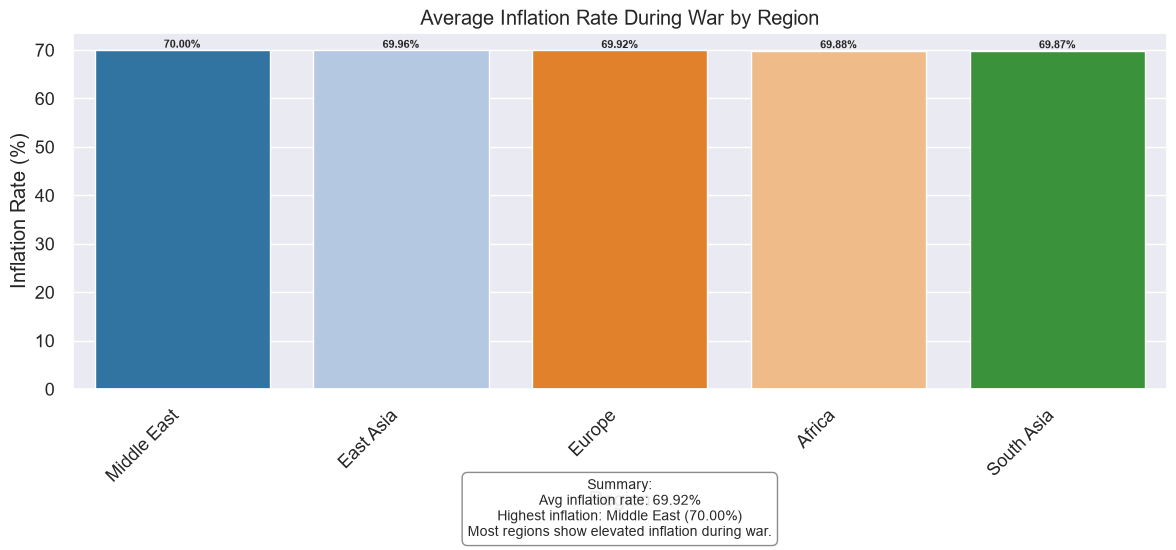

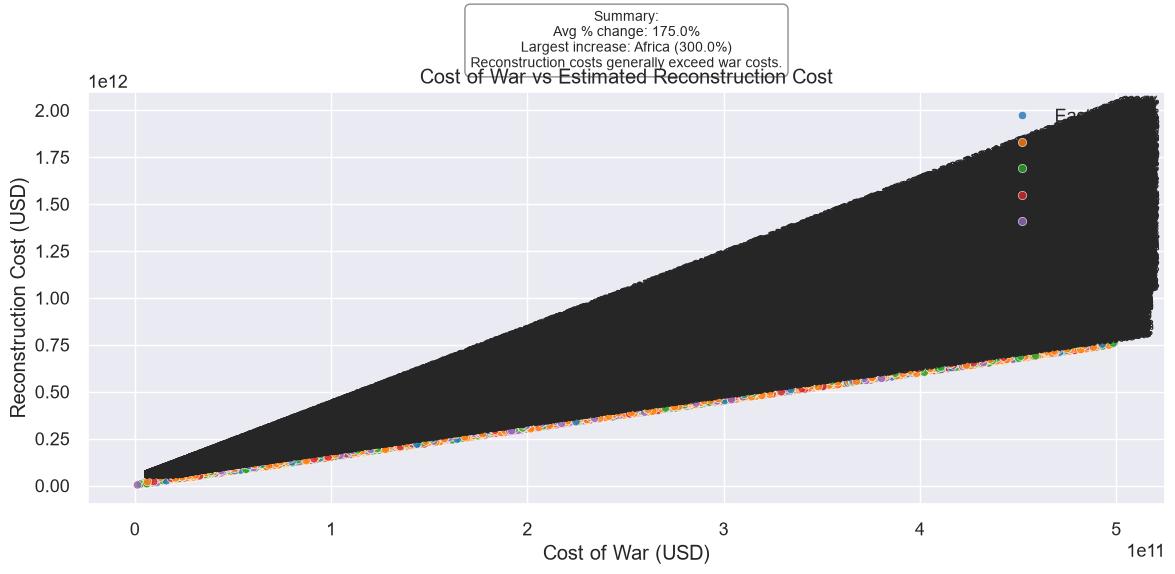

C:\Users\kefya\AppData\Local\Temp\ipykernel_20352\39271907.py:419: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


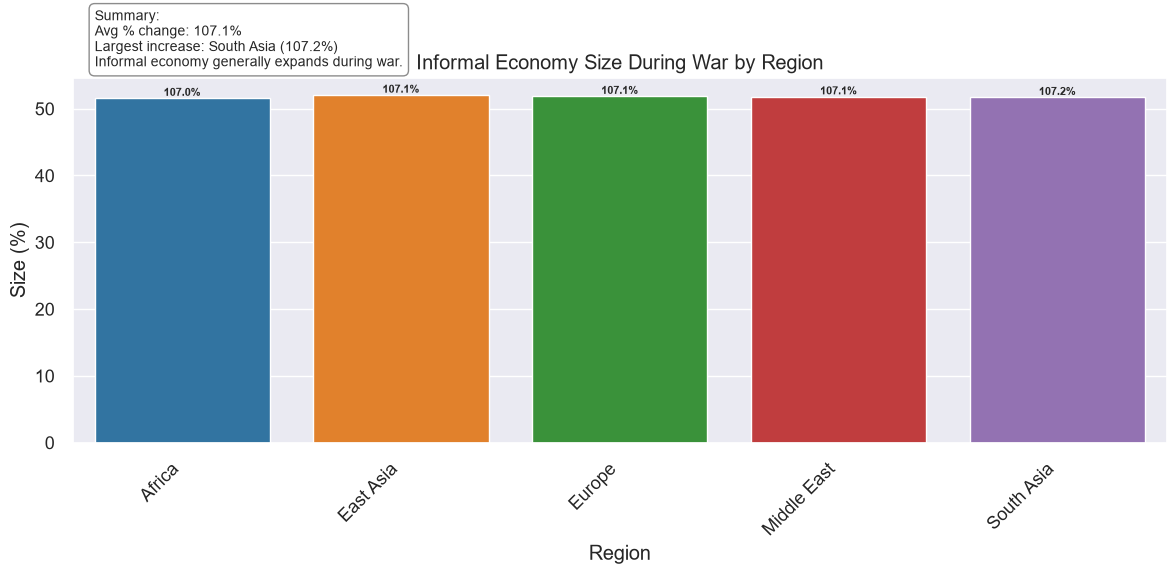

C:\Users\kefya\AppData\Local\Temp\ipykernel_20352\39271907.py:527: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\kefya\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


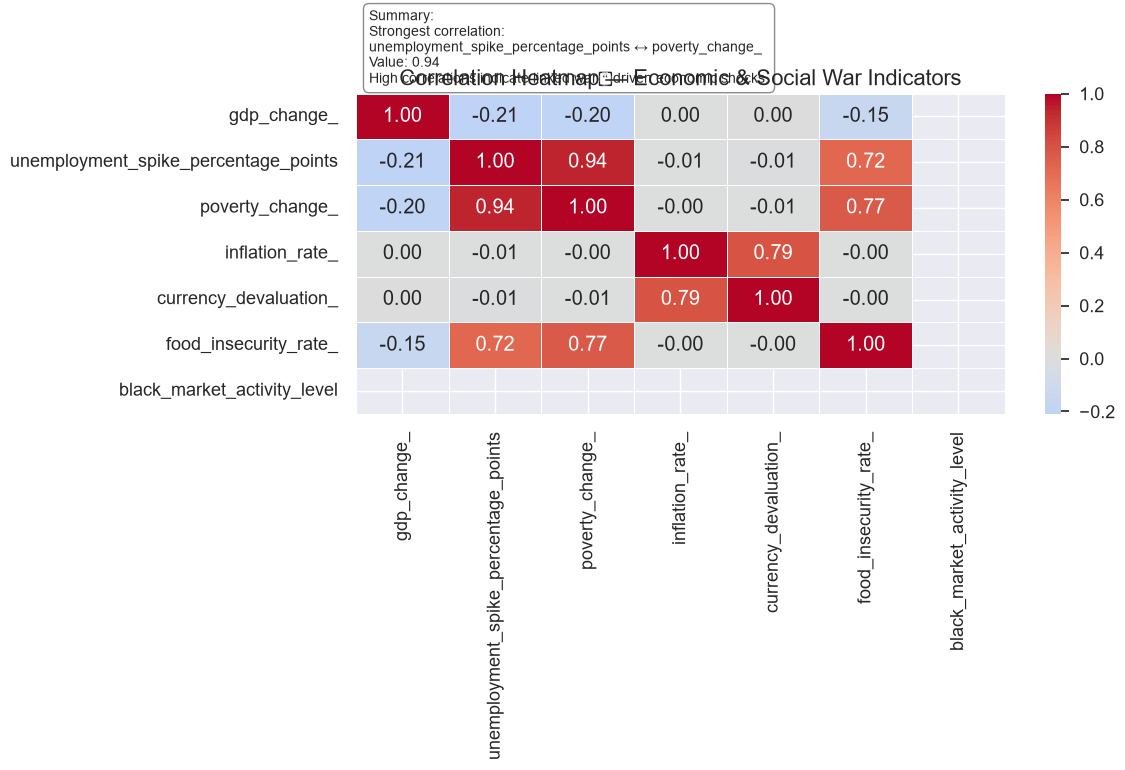


KPI 7 – Strongest correlation between indicators:
unemployment_spike_percentage_points  poverty_change_    0.941142
dtype: float64


In [1]:
#  ECONOMY — CLEANED, FIXED & COMPLETED SCRIPT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

# ============================================================
# 1. Load data
# ============================================================
df = pd.read_csv("war_economic_impact_dataset.csv")

# ============================================================
# 2. Inspect data
# ============================================================
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nHead:\n", df.head())
print("\nSample:\n", df.sample(5, random_state=42))
print("\nInfo:")
df.info()
print("\nDescribe (numeric):")
print(df.describe())
print("\nDescribe (all):")
print(df.describe(include="all"))
print("\nMissing per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# ============================================================
# 3–4. Clean, strip, standardize, replace NaN numeric with median
# ============================================================

df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace(r"[^0-9a-zA-Z_]", "", regex=True)
)

str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

for col in ["conflict_name", "conflict_type", "region", "status", "most_affected_sector", "primary_country"]:
    if col in df.columns:
        df[col] = df[col].str.title()

num_candidates = [
    "pre_war_unemployment_",
    "during_war_unemployment_",
    "unemployment_spike_percentage_points",
    "youth_unemployment_change_",
    "pre_war_poverty_rate_",
    "during_war_poverty_rate_",
    "extreme_poverty_rate_",
    "food_insecurity_rate_",
    "households_fallen_into_poverty_estimate",
    "gdp_change_",
    "inflation_rate_",
    "currency_devaluation_",
    "cost_of_war_usd",
    "estimated_reconstruction_cost_usd",
    "informal_economy_size_pre_war_",
    "informal_economy_size_during_war_",
    "currency_black_market_rate_gap_",
    "black_market_activity_level"
]
for col in num_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df_clean = df.copy()

num_cols = df_clean.select_dtypes(include=["float64","int64","Int64"]).columns
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

cat_cols = df_clean.select_dtypes(include="object").columns
for col in cat_cols:
    mode = df_clean[col].mode()
    df_clean[col] = df_clean[col].fillna(mode.iloc[0] if not mode.empty else "Unknown")

print("\nMissing after imputation:\n", df_clean.isna().sum())

# ============================================================
# 5. Handle missing values & date parse
# ============================================================
for col in ["start_year", "end_year"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").astype("Int64")

# ============================================================
# 6. Pivot for increase/decrease trend (NEW)
# ============================================================
if "start_year" in df_clean.columns and "gdp_change_" in df_clean.columns:
    pivot = df_clean.groupby("start_year")[["gdp_change_", "inflation_rate_", "unemployment_spike_percentage_points"]].mean()
    pivot["gdp_yoy"] = pivot["gdp_change_"].pct_change() * 100
    pivot["inflation_yoy"] = pivot["inflation_rate_"].pct_change() * 100
    pivot["unemployment_yoy"] = pivot["unemployment_spike_percentage_points"].pct_change() * 100

    print("\nPivot YoY Trend Table:\n", pivot.head())

# ============================================================
# PLOT 1 — GDP CHANGE BY CONFLICT
# ============================================================

if {"conflict_name","gdp_change_"}.issubset(df_clean.columns):

    plot_data = df_clean.sort_values("gdp_change_")

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=plot_data,
        x="conflict_name",
        y="gdp_change_",
        hue="conflict_name",
        palette="Set2",
        legend=False
    )

    plt.xticks(rotation=90)
    plt.title("GDP Change During War by Conflict")
    plt.xlabel("Conflict")
    plt.ylabel("GDP Change (%)")

    for p, val in zip(ax.patches, plot_data["gdp_change_"]):
        ax.annotate(
            f"{val:.1f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    avg_change = plot_data["gdp_change_"].mean()
    worst_conflict = plot_data.loc[plot_data["gdp_change_"].idxmin(), "conflict_name"]
    worst_value = plot_data["gdp_change_"].min()

    summary_text = (
        f"Summary:\n"
        f"Average GDP change: {avg_change:.1f}%\n"
        f"Worst impact: {worst_conflict} ({worst_value:.1f}%)\n"
        f"Most conflicts show GDP decline during war."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, -0.25),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# PLOT 2 — UNEMPLOYMENT SPIKE
# ============================================================

required_cols = {"conflict_name","unemployment_spike_percentage_points"}
missing = required_cols - set(df_clean.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

plot_data = df_clean.sort_values("unemployment_spike_percentage_points", ascending=False)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=plot_data,
    x="conflict_name",
    y="unemployment_spike_percentage_points",
    hue="conflict_name",
    palette="tab10",
    legend=False
)

plt.xticks(rotation=90)
plt.title("Unemployment Spike During War by Conflict")
plt.xlabel("Conflict")
plt.ylabel("Spike (percentage points)")

for p, val in zip(ax.patches, plot_data["unemployment_spike_percentage_points"]):
    ax.annotate(
        f"{val:.1f} pp",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

avg_spike = plot_data["unemployment_spike_percentage_points"].mean()
max_conflict = plot_data.loc[plot_data["unemployment_spike_percentage_points"].idxmax(), "conflict_name"]
max_value = plot_data["unemployment_spike_percentage_points"].max()

summary_text = (
        f"Summary:\n"
        f"Avg unemployment spike: {avg_spike:.1f} pp\n"
        f"Highest spike: {max_conflict} ({max_value:.1f} pp)\n"
        f"Most conflicts show increased unemployment during war."
)

ax.annotate(
    summary_text,
    xy=(0.5, -0.25),
    xycoords="axes fraction",
    ha="center",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3 — POVERTY CHANGE
# ============================================================

if {"conflict_name","pre_war_poverty_rate_","during_war_poverty_rate_"}.issubset(df_clean.columns):

    df_clean["poverty_change_"] = df_clean["during_war_poverty_rate_"] - df_clean["pre_war_poverty_rate_"]
    plot_data = df_clean.sort_values("poverty_change_", ascending=False)

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=plot_data,
        x="conflict_name",
        y="poverty_change_",
        hue="conflict_name",
        palette="Set3",
        legend=False
    )

    plt.xticks(rotation=90)
    plt.title("Change in Poverty Rate Due to War by Conflict")
    plt.xlabel("Conflict")
    plt.ylabel("Poverty Change (percentage points)")

    for p, val in zip(ax.patches, plot_data["poverty_change_"]):
        ax.annotate(
            f"{val:.1f} pp",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    avg_change = plot_data["poverty_change_"].mean()
    worst_conflict = plot_data.loc[plot_data["poverty_change_"].idxmax(), "conflict_name"]
    worst_value = plot_data["poverty_change_"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg poverty change: {avg_change:.1f} pp\n"
        f"Largest increase: {worst_conflict} ({worst_value:.1f} pp)\n"
        f"Most conflicts show rising poverty during war."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, -0.25),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# PLOT 4 — INFLATION RATE BY REGION
# ============================================================

if {"region","inflation_rate_"}.issubset(df_clean.columns):

    infl_region = df_clean.groupby("region")["inflation_rate_"].mean().reset_index()
    infl_region = infl_region.sort_values("inflation_rate_", ascending=False)

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=infl_region,
        x="region",
        y="inflation_rate_",
        hue="region",
        palette="tab20",
        legend=False
    )

    plt.xticks(rotation=45, ha="right")
    plt.title("Average Inflation Rate During War by Region")
    plt.xlabel("Region")
    plt.ylabel("Inflation Rate (%)")

    for p, val in zip(ax.patches, infl_region["inflation_rate_"]):
        ax.annotate(
            f"{val:.2f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    avg_infl = infl_region["inflation_rate_"].mean()
    highest_region = infl_region.loc[infl_region["inflation_rate_"].idxmax(), "region"]
    highest_value = infl_region["inflation_rate_"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg inflation rate: {avg_infl:.2f}%\n"
        f"Highest inflation: {highest_region} ({highest_value:.2f}%)\n"
        f"Most regions show elevated inflation during war."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, -0.25),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# PLOT 5 — COST OF WAR VS RECONSTRUCTION COST
# ============================================================

if {"cost_of_war_usd","estimated_reconstruction_cost_usd","region"}.issubset(df_clean.columns):

    plt.figure(figsize=(12,6))
    ax = sns.scatterplot(
        data=df_clean,
        x="cost_of_war_usd",
        y="estimated_reconstruction_cost_usd",
        hue="region",
        palette="tab10",
        alpha=0.8
    )

    plt.legend(loc="upper right")
    plt.title("Cost of War vs Estimated Reconstruction Cost")
    plt.xlabel("Cost of War (USD)")
    plt.ylabel("Reconstruction Cost (USD)")

    df_clean["pct_change"] = (
        (df_clean["estimated_reconstruction_cost_usd"] - df_clean["cost_of_war_usd"])
        / df_clean["cost_of_war_usd"]
    ) * 100

    for i, row in df_clean.iterrows():
        ax.annotate(
            f"{row['pct_change']:.1f}%",
            (row["cost_of_war_usd"], row["estimated_reconstruction_cost_usd"]),
            textcoords="offset points",
            xytext=(5,5),
            fontsize=8,
            fontweight="bold"
        )

    avg_pct_change = df_clean["pct_change"].mean()
    max_region = df_clean.loc[df_clean["pct_change"].idxmax(), "region"]
    max_value = df_clean["pct_change"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg % change: {avg_pct_change:.1f}%\n"
        f"Largest increase: {max_region} ({max_value:.1f}%)\n"
        f"Reconstruction costs generally exceed war costs."
    )

    ax.annotate(
        summary_text,
        xy=(0.5, 1.05),
        xycoords="axes fraction",
        ha="center",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# PLOT 6 — INFORMAL ECONOMY PRE VS DURING WAR
# ============================================================

if {"region","informal_economy_size_pre_war_","informal_economy_size_during_war_"}.issubset(df_clean.columns):

    inf_region = df_clean.groupby("region")[[
        "informal_economy_size_pre_war_",
        "informal_economy_size_during_war_"
    ]].mean().reset_index()

    inf_region["pct_change"] = (
        (inf_region["informal_economy_size_during_war_"] -
         inf_region["informal_economy_size_pre_war_"])
        / inf_region["informal_economy_size_pre_war_"]
    ) * 100

    plt.figure(figsize=(12,6))
    ax = sns.barplot(
        data=inf_region,
        x="region",
        y="informal_economy_size_during_war_",
        palette="tab10"
    )

    plt.title("Informal Economy Size During War by Region")
    plt.xlabel("Region")
    plt.ylabel("Size (%)")
    plt.xticks(rotation=45, ha="right")

    for p, val in zip(ax.patches, inf_region["pct_change"]):
        ax.annotate(
            f"{val:.1f}%",
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

    avg_change = inf_region["pct_change"].mean()
    max_region = inf_region.loc[inf_region["pct_change"].idxmax(), "region"]
    max_value = inf_region["pct_change"].max()

    summary_text = (
        f"Summary:\n"
        f"Avg % change: {avg_change:.1f}%\n"
        f"Largest increase: {max_region} ({max_value:.1f}%)\n"
        f"Informal economy generally expands during war."
    )

    ax.annotate(
        summary_text,
        xy=(0.02, 1.02),
        xycoords="axes fraction",
        ha="left",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

# ============================================================
# PLOT 7 — CORRELATION HEATMAP (FIXED & COMPLETED)
# ============================================================

corr_cols = [
    "gdp_change_",
    "unemployment_spike_percentage_points",
    "poverty_change_" if "poverty_change_" in df_clean.columns else None,
    "inflation_rate_",
    "currency_devaluation_",
    "food_insecurity_rate_",
    "black_market_activity_level"
]

# Remove None values and keep only existing columns
corr_cols = [c for c in corr_cols if c is not None and c in df_clean.columns]

if len(corr_cols) >= 2:

    corr_matrix = df_clean[corr_cols].corr()

    plt.figure(figsize=(12, 8))
    ax = sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        fmt=".2f"
    )

    plt.title("Correlation Heatmap — Economic & Social War Indicators", fontsize=16)

    # ===== Summary Box (Top Left) =====
    strongest_pair = (
        corr_matrix.abs()
        .unstack()
        .sort_values(ascending=False)
    )

    strongest_pair = strongest_pair[strongest_pair < 1].head(1)
    strongest_vars = strongest_pair.index[0]
    strongest_value = strongest_pair.values[0]

    summary_text = (
        f"Summary:\n"
        f"Strongest correlation:\n"
        f"{strongest_vars[0]} ↔ {strongest_vars[1]}\n"
        f"Value: {strongest_value:.2f}\n"
        f"High correlations indicate linked war‑driven economic shocks."
    )

    ax.annotate(
        summary_text,
        xy=(0.02, 1.02),
        xycoords="axes fraction",
        ha="left",
        va="bottom",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()

    print("\nKPI 7 – Strongest correlation between indicators:")
    print(strongest_pair)

else:
    print("Not enough numeric columns available for correlation heatmap.")